<a href="https://colab.research.google.com/github/Ariel-Pineapple/qc-anomaly-detection-isolation-forest/blob/main/Exploratory_Data_Analysis_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

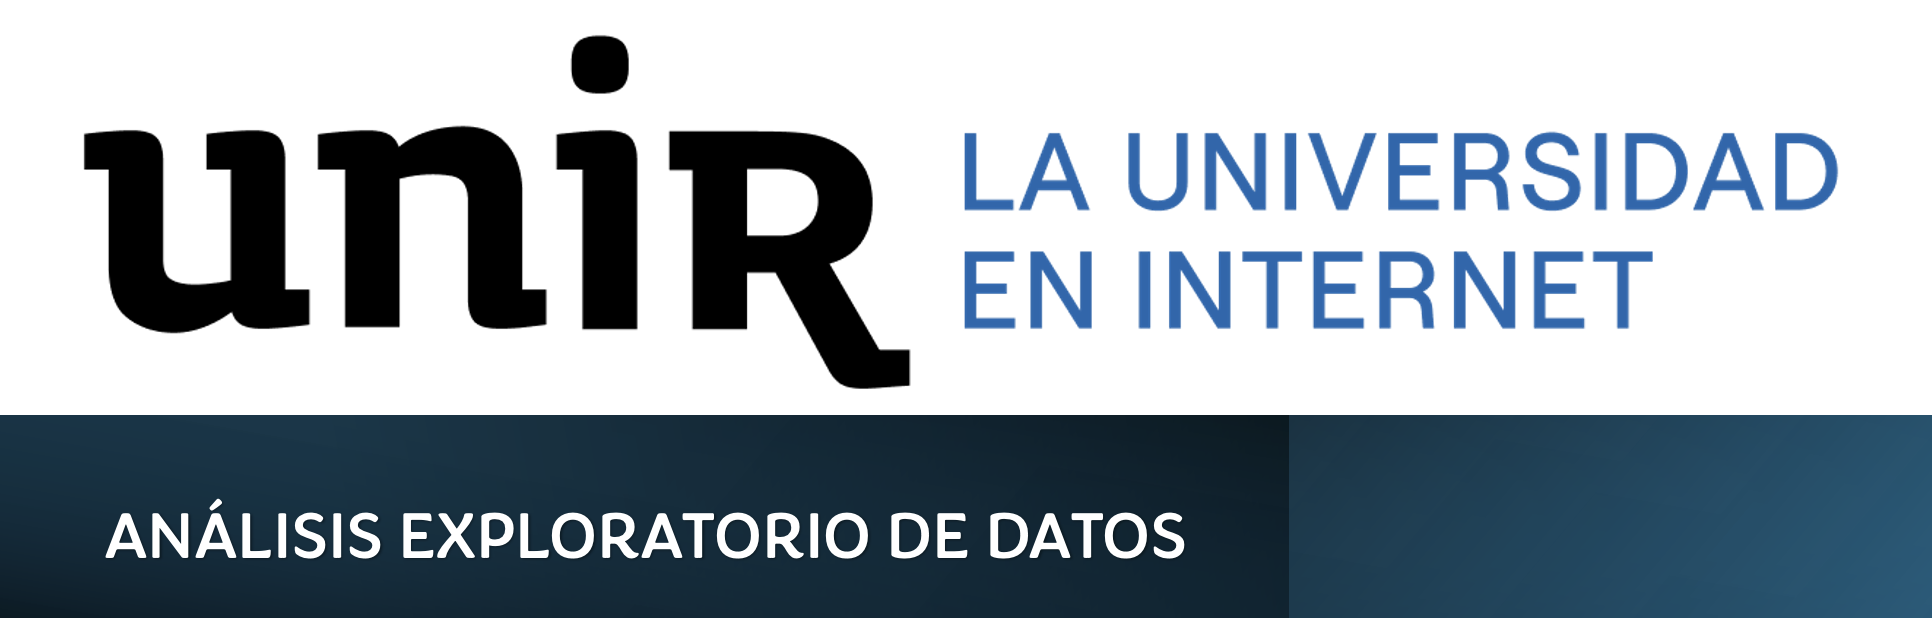

# Exploratory Data Analysis (EDA) del Dataset Sintético de Control de Calidad

**Proyecto:** Detección de anomalías en control de calidad de inmunoensayos  
**Modelo:** Isolation Forest  
**Autor(es):** Equipo 3004D  
**Fecha:** 2026  

---

## Objetivo

Analizar el comportamiento del dataset sintético generado para control de calidad en inmunoensayos, identificando patrones de normalidad, variabilidad y presencia de drifts, con el fin de validar su adecuación para el entrenamiento y evaluación de modelos de detección de anomalías.

---

## Descripción del dataset

El dataset contiene registros simulados de valores S/CO con las siguientes características:

- Serie temporal de mediciones
- Segmentos normales y con anomalías controladas
- Etiquetas de referencia (`estado_real`)
- Tipos de drift (`lineal`, `escalonado`, `aleatorio`)

# 1. Importación de Librerías

In [1]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use("default")
sns.set_theme()

# Mostrar todas las columnas
pd.set_option("display.max_columns", None)

# 2. Carga del dataset

## Carga del dataset

En esta sección se carga el dataset sintético previamente generado, el cual simula el comportamiento de valores S/CO en procesos de control de calidad.

In [2]:
df = pd.read_csv("dataset_qc_sintetico.csv")

df.head()

,id_registro,fecha,analito,lote,equipo,sco,estado_real,tipo_drift
0,1,2025-01-01,VIH,L001,E01,1.0248,0,normal
1,2,2025-01-02,VIH,L001,E01,0.9931,0,normal
2,3,2025-01-03,VIH,L001,E01,1.0324,0,normal
3,4,2025-01-04,VIH,L001,E01,1.0762,0,normal
4,5,2025-01-05,VIH,L001,E01,0.9883,0,normal


# 3. Inspección General


## Inspección general de la estructura del dataset

Se revisa la dimensionalidad, tipos de datos y presencia de valores nulos.

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_registro  360 non-null    int64  
 1   fecha        360 non-null    object 
 2   analito      360 non-null    object 
 3   lote         360 non-null    object 
 4   equipo       360 non-null    object 
 5   sco          360 non-null    float64
 6   estado_real  360 non-null    int64  
 7   tipo_drift   360 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 22.6+ KB


,0
id_registro,0
fecha,0
analito,0
lote,0
equipo,0
sco,0
estado_real,0
tipo_drift,0


# 4. Distribución de la variable S/CO


## Distribución de los valores S/CO

Se analiza la distribución de los valores para identificar sesgos, dispersión y posibles desviaciones respecto a un comportamiento esperado.

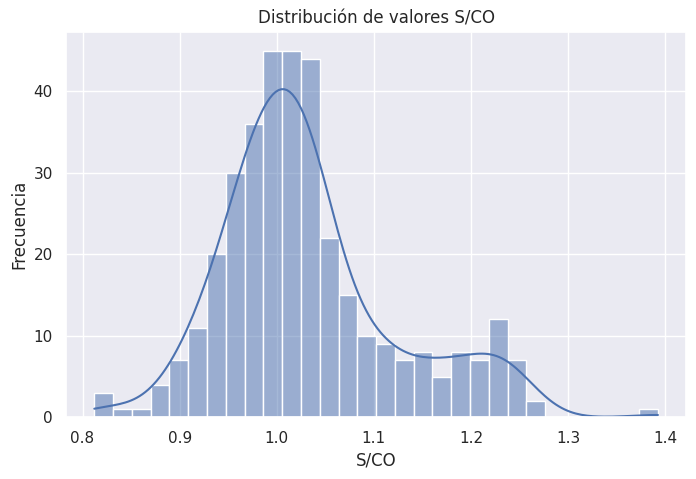

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["sco"], bins=30, kde=True)
plt.title("Distribución de valores S/CO")
plt.xlabel("S/CO")
plt.ylabel("Frecuencia")
plt.show()

# 5. Serie temporal

## Análisis temporal de los valores S/CO

Se visualiza la evolución de los valores S/CO a lo largo del tiempo para identificar patrones, tendencias y posibles anomalías.

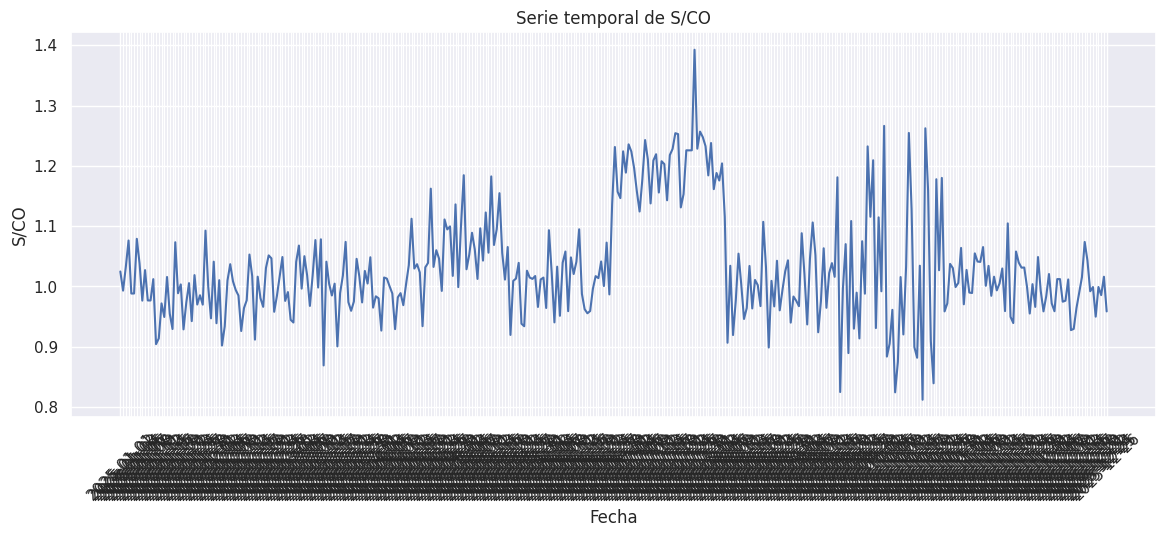

In [5]:
plt.figure(figsize=(14,5))
plt.plot(df["fecha"], df["sco"])
plt.title("Serie temporal de S/CO")
plt.xlabel("Fecha")
plt.ylabel("S/CO")
plt.xticks(rotation=45)
plt.show()

6. Identificación de anomalías reales


## Identificación de segmentos anómalos

Se resaltan los puntos etiquetados como anomalías para validar la coherencia del dataset sintético.

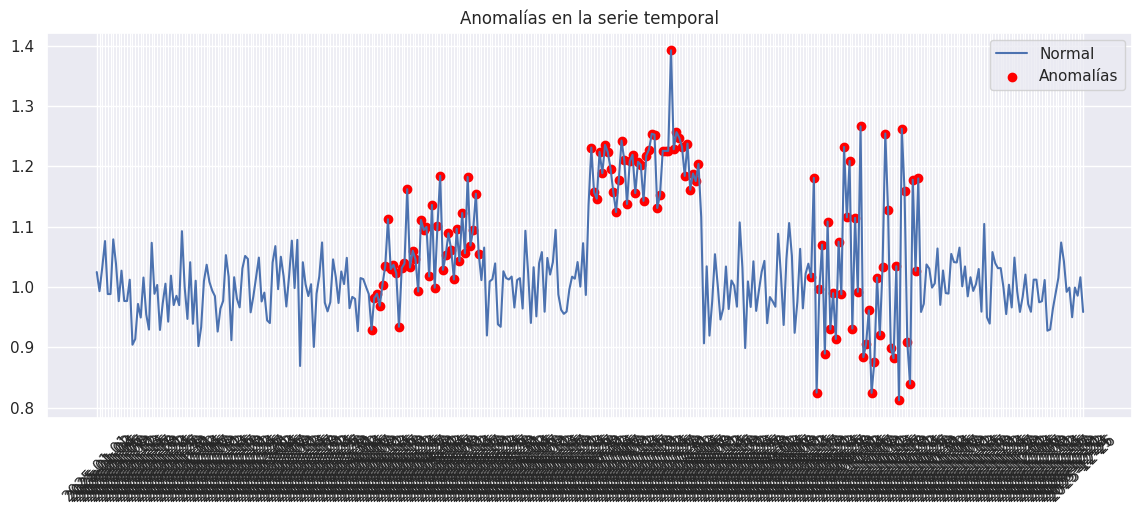

In [6]:
plt.figure(figsize=(14,5))
plt.plot(df["fecha"], df["sco"], label="Normal")

anomalias = df[df["estado_real"] == 1]

plt.scatter(anomalias["fecha"], anomalias["sco"], color="red", label="Anomalías")

plt.legend()
plt.title("Anomalías en la serie temporal")
plt.xticks(rotation=45)
plt.show()

7. Distribución por tipo de drift

## Distribución de tipos de drift

Se analiza la proporción de cada tipo de anomalía en el dataset.

In [7]:
df["tipo_drift"].value_counts()

,count
tipo_drift,
normal,240
lineal,40
escalonado,40
aleatorio,40


In [8]:
df["tipo_drift"].value_counts()

,count
tipo_drift,
normal,240
lineal,40
escalonado,40
aleatorio,40


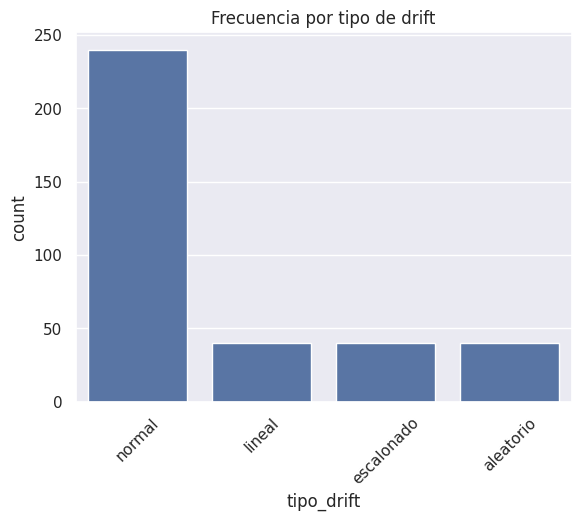

In [9]:
sns.countplot(data=df, x="tipo_drift")
plt.title("Frecuencia por tipo de drift")
plt.xticks(rotation=45)
plt.show()

# 8. Comparación normal vs anómalo

## Comparación entre comportamiento normal y anómalo

Se evalúan diferencias en distribución entre datos normales y anómalos.

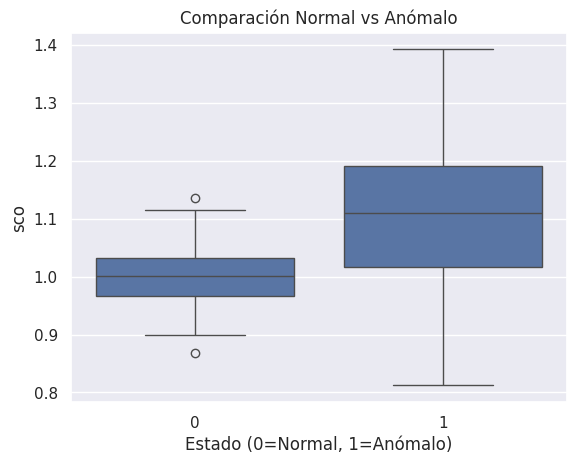

In [10]:
sns.boxplot(data=df, x="estado_real", y="sco")
plt.title("Comparación Normal vs Anómalo")
plt.xlabel("Estado (0=Normal, 1=Anómalo)")
plt.show()

# 9. Análisis por lote


## Análisis por lote

Se analiza la variabilidad de los valores S/CO en función del lote.

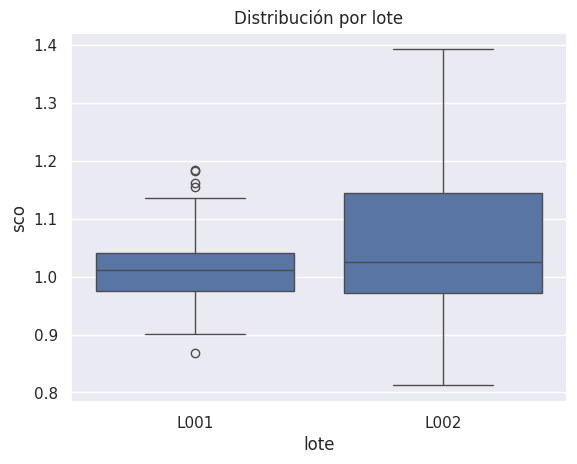

In [11]:
sns.boxplot(data=df, x="lote", y="sco")
plt.title("Distribución por lote")
plt.show()

# 10. Conclusiones del EDA

## Conclusiones del análisis exploratorio

- El dataset presenta una distribución coherente con valores S/CO simulados.
- Se observan claramente segmentos con comportamiento anómalo.
- Los drifts lineales, escalonados y aleatorios son distinguibles visualmente.
- La proporción de anomalías permite evaluar modelos de detección sin sesgo extremo.
- El dataset es adecuado para entrenamiento y validación de modelos de detección de anomalías.

Este análisis valida la calidad del dataset sintético como base experimental del proyecto.

## Limitaciones

- Los datos son simulados y no reflejan completamente la complejidad clínica real.
- No se consideran variables externas (temperatura, operador, calibración).